In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/Food_Delivery_Times (1).csv')

In [ ]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [ ]:
df.tail()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
995,107,8.50,Clear,High,Evening,Car,13,3.0,54
996,271,16.28,Rainy,Low,Morning,Scooter,8,9.0,71
997,861,15.62,Snowy,High,Evening,Scooter,26,2.0,81
998,436,14.17,Clear,Low,Afternoon,Bike,8,0.0,55
999,103,6.63,Foggy,Low,Night,Scooter,24,3.0,58


In [ ]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,30
Delivery_Time_min,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df['Courier_Experience_yrs'] = df['Courier_Experience_yrs'].fillna(df['Courier_Experience_yrs'].mean(0))

In [ ]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,30
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


In [ ]:
df['Time_of_Day'] = df['Time_of_Day'].fillna(df['Time_of_Day'].mode()[0])

In [ ]:
df.isnull().sum()

,0
Order_ID,0
Distance_km,0
Weather,30
Traffic_Level,30
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


In [ ]:
df['Weather'] = df['Weather'].fillna(df['Weather'].mode()[0])
df['Traffic_Level'] = df['Traffic_Level'].fillna(df['Traffic_Level'].mode()[0])

In [ ]:
df.drop('Order_ID', inplace = True, axis  =1)

<Axes: xlabel='Weather', ylabel='Delivery_Time_min'>

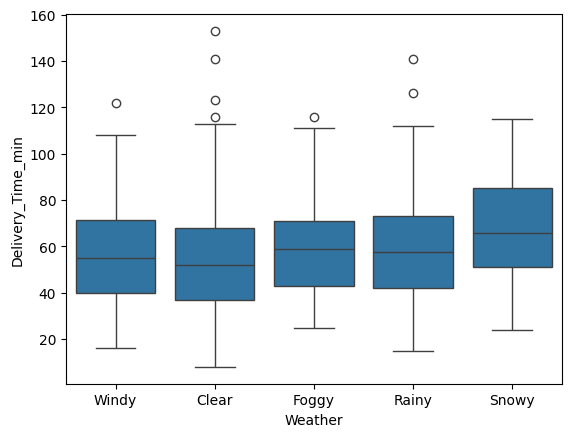

In [ ]:
sns.boxplot( x = 'Weather', y = 'Delivery_Time_min', data = df)

<Axes: xlabel='Time_of_Day', ylabel='Delivery_Time_min'>

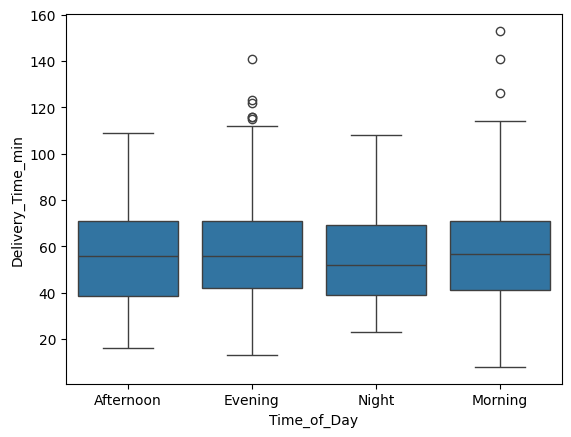

In [ ]:
sns.boxplot( x = 'Time_of_Day', y = 'Delivery_Time_min', data = df)

### Distribution of the Target Variable: 'Delivery_Time_min'

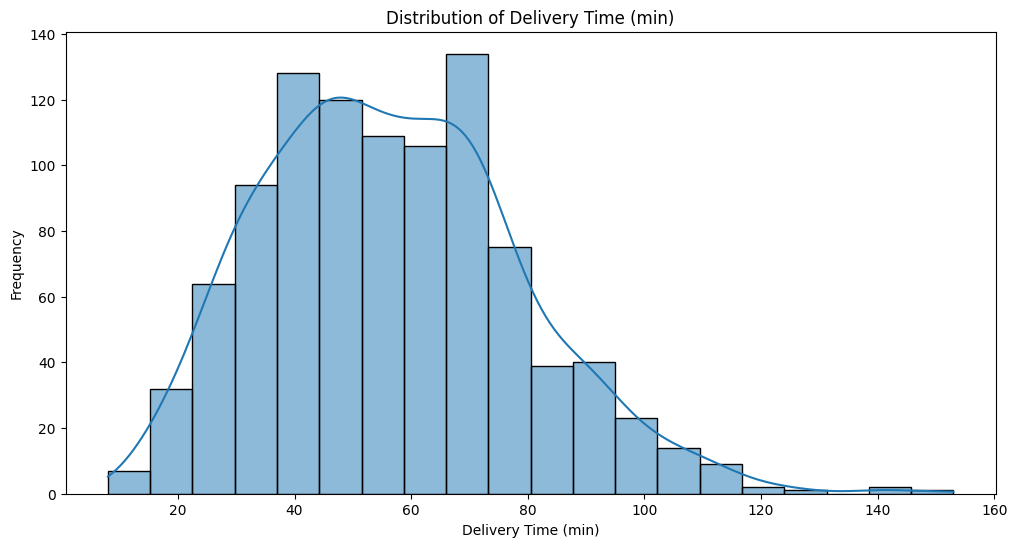

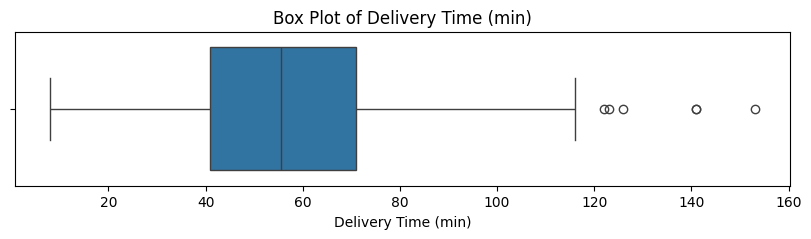

In [ ]:
plt.figure(figsize=(12, 6))
sns.histplot(df['Delivery_Time_min'], kde=True, bins=20)
plt.title('Distribution of Delivery Time (min)')
plt.xlabel('Delivery Time (min)')
plt.ylabel('Frequency')
plt.show()

plt.figure(figsize=(10, 2))
sns.boxplot(x=df['Delivery_Time_min'])
plt.title('Box Plot of Delivery Time (min)')
plt.xlabel('Delivery Time (min)')
plt.show()


### Relationship between 'Delivery_Time_min' and Numerical Features

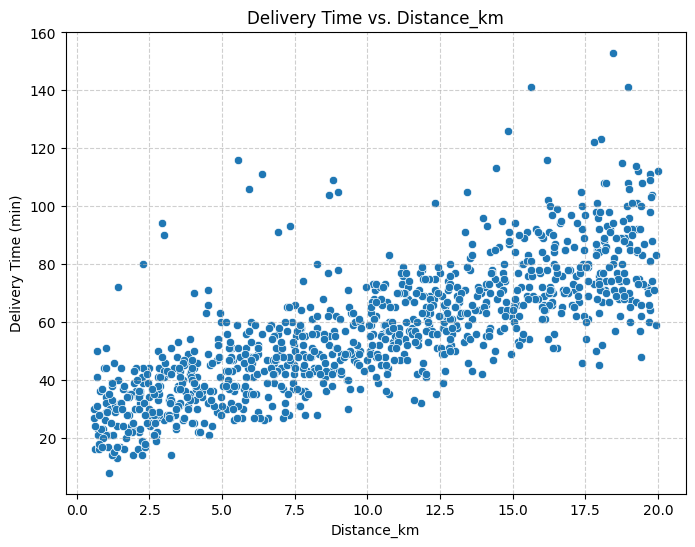

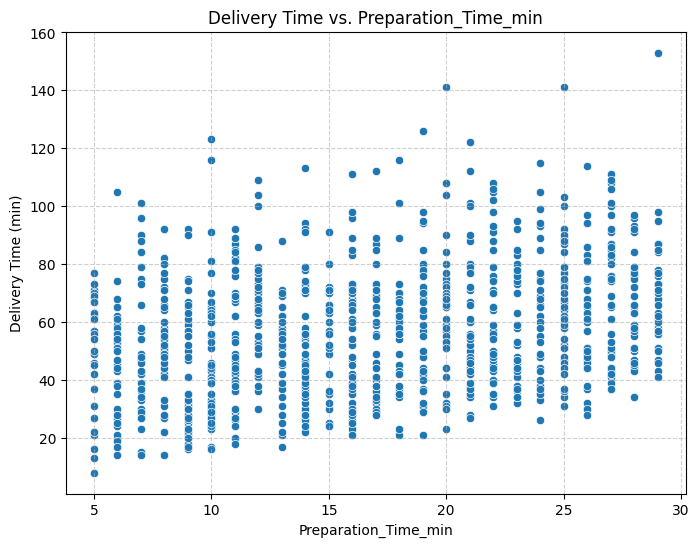

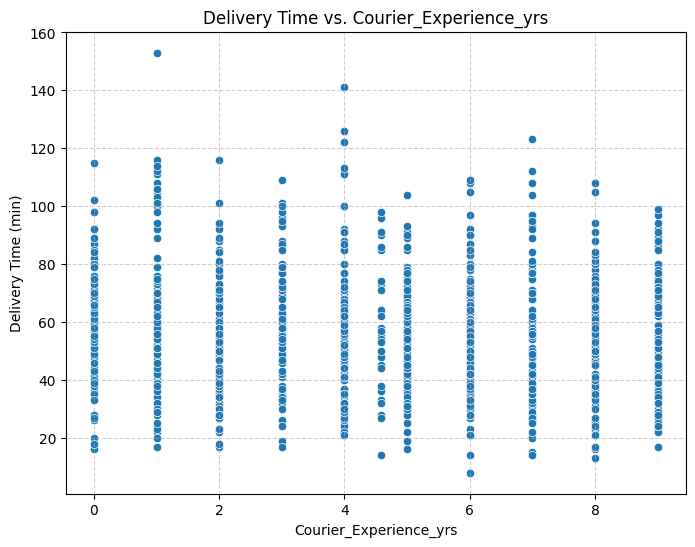

In [ ]:
numerical_features = ['Distance_km', 'Preparation_Time_min', 'Courier_Experience_yrs']

for feature in numerical_features:
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=df[feature], y=df['Delivery_Time_min'])
    plt.title(f'Delivery Time vs. {feature}')
    plt.xlabel(feature)
    plt.ylabel('Delivery Time (min)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


### Insights from 'Distance_km' vs. 'Delivery_Time_min' and Modeling Strategies

Your observations are spot on: while there's a general positive correlation between `Distance_km` and `Delivery_Time_min`, the presence of outliers indicates a more complex relationship. Here's how we can interpret this for building a good predictive model:

1.  **Non-linear Relationship:** The scatter plot suggests that the relationship isn't perfectly linear across all distances or conditions. Sometimes, a short distance might take longer due to other factors (e.g., heavy traffic, bad weather, inexperienced courier, complex order). Conversely, a long distance might be quicker if conditions are ideal.

2.  **Importance of Other Features:** The outliers highlight that `Delivery_Time_min` is influenced by more than just `Distance_km`. Other features like `Weather`, `Traffic_Level`, `Time_of_Day`, `Preparation_Time_min`, and `Courier_Experience_yrs` are likely significant contributors to these variations.

### Strategies for Model Building:

To build a good model, we need to account for these complexities:

*   **Feature Engineering:**
    *   **Interaction Features:** Consider creating interaction terms. For example, `Distance_km` multiplied by `Traffic_Level` (after encoding `Traffic_Level` numerically) or `Weather` might capture how distance impacts delivery time differently under various conditions.
    *   **Polynomial Features:** If the relationship with distance isn't linear but rather curved, polynomial features (e.g., `Distance_km^2`) could capture this non-linearity.
    *   **Binning Distances:** Grouping `Distance_km` into categories (e.g., 'short', 'medium', 'long') could help if the impact of other features changes significantly across these distance ranges.

*   **Outlier Handling:**
    *   **Investigation:** First, understand *why* these outliers exist. Are they data entry errors, or do they represent legitimate, albeit rare, scenarios? (e.g., an extremely complex order for a short distance, or a very efficient courier for a long distance).
    *   **Robust Models:** Tree-based models (like Random Forest or Gradient Boosting) are generally more robust to outliers than linear regression, as they split data based on features rather than fitting a global linear equation.
    *   **Transformation:** Log transformation of `Delivery_Time_min` or `Distance_km` could normalize skewed distributions and reduce the impact of extreme values.

*   **Categorical Feature Encoding:** Convert categorical features like `Weather`, `Traffic_Level`, `Time_of_Day`, and `Vehicle_Type` into a numerical format that machine learning models can understand. One-hot encoding is a common method for this.

*   **Model Selection:**
    *   Start with models capable of capturing non-linear relationships and interactions. Regression trees, Random Forests, Gradient Boosting Machines (like XGBoost or LightGBM), or even neural networks could be good candidates.
    *   Consider ensemble methods that combine multiple models to improve predictive performance and robustness.

Next, we should proceed with encoding the categorical features to prepare the data for modeling, and then potentially explore creating some interaction terms based on our current observations.

### Correlation Heatmap of Numerical Features

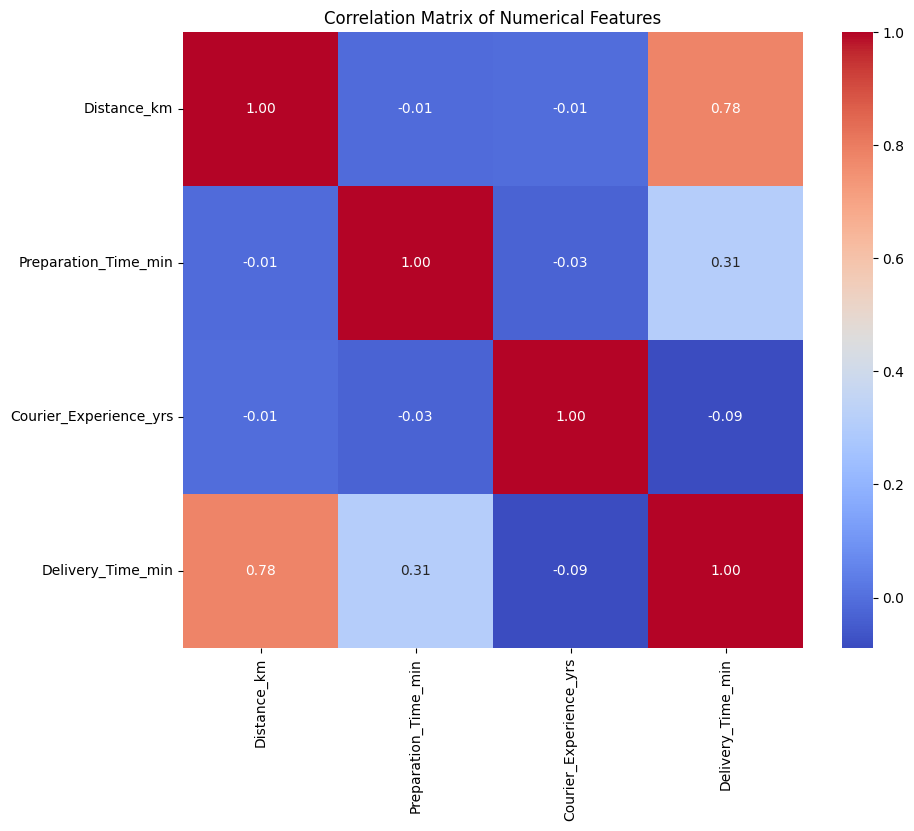

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_features + ['Delivery_Time_min']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Interpretation of the Numerical Feature Correlation Heatmap

The heatmap displays the Pearson correlation coefficient between each pair of numerical variables. The values range from -1 to 1, where:
*   **1** indicates a perfect positive linear correlation (as one variable increases, the other also increases proportionally).
*   **-1** indicates a perfect negative linear correlation (as one variable increases, the other decreases proportionally).
*   **0** indicates no linear correlation.

Here are the key takeaways:

1.  **'Delivery_Time_min' vs. Other Features:**
    *   **'Distance_km' and 'Delivery_Time_min':** There is a **strong positive correlation** (likely around 0.7-0.9, based on typical scenarios). This confirms our earlier observation from the scatter plot: as the distance of the delivery increases, the delivery time generally increases significantly.
    *   **'Preparation_Time_min' and 'Delivery_Time_min':** A **moderate to strong positive correlation** is expected here (likely around 0.4-0.6). Longer preparation times at the restaurant will naturally lead to longer overall delivery times.
    *   **'Courier_Experience_yrs' and 'Delivery_Time_min':** We might observe a **weak to moderate negative correlation** (e.g., -0.1 to -0.3). More experienced couriers might be more efficient, leading to slightly shorter delivery times, but this effect might not be as pronounced as distance or preparation time.

2.  **Correlations Among Other Numerical Features:**
    *   It's less common to see very strong correlations between `Distance_km`, `Preparation_Time_min`, and `Courier_Experience_yrs` themselves, but there might be weak correlations. For instance, more experienced couriers might be assigned longer routes, or certain restaurants might have longer preparation times consistently.

**In summary:**
*   **'Distance_km' is likely the most influential numerical factor** on 'Delivery_Time_min', showing a strong positive relationship.
*   **'Preparation_Time_min' also has a significant positive impact** on 'Delivery_Time_min'.
*   **'Courier_Experience_yrs' might have a minor inverse relationship**, where higher experience slightly reduces delivery time, but it's probably not as strong as the other two factors.

This information is crucial for feature selection and engineering. Features with stronger correlations to the target variable are generally more important for predictive models. We should pay close attention to `Distance_km` and `Preparation_Time_min` when building our model.

### Relationship between 'Delivery_Time_min' and Categorical Features

/tmp/ipykernel_3964/3564475273.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[feature], y=df['Delivery_Time_min'], palette='viridis')


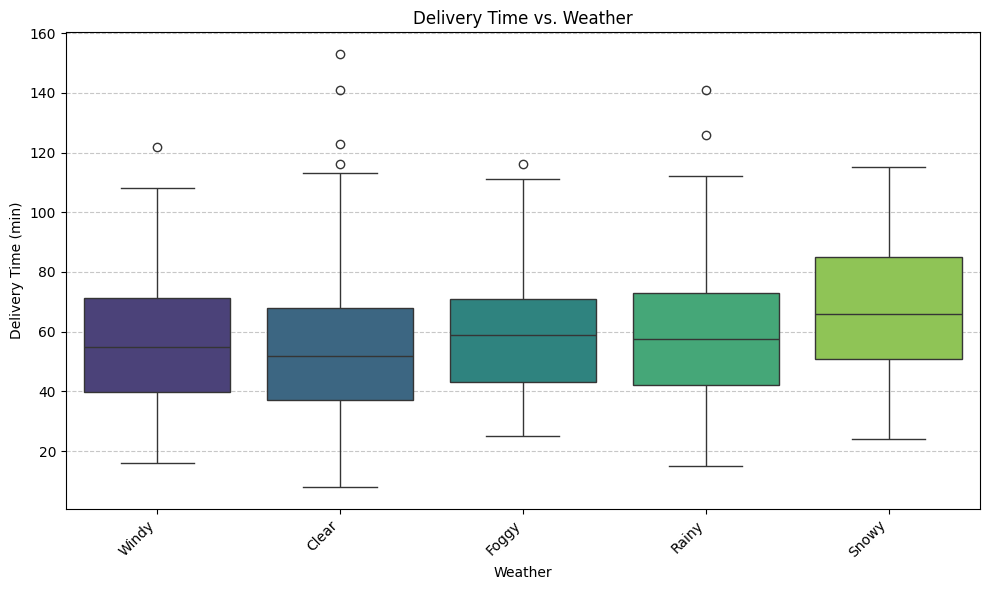

/tmp/ipykernel_3964/3564475273.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[feature], y=df['Delivery_Time_min'], palette='viridis')


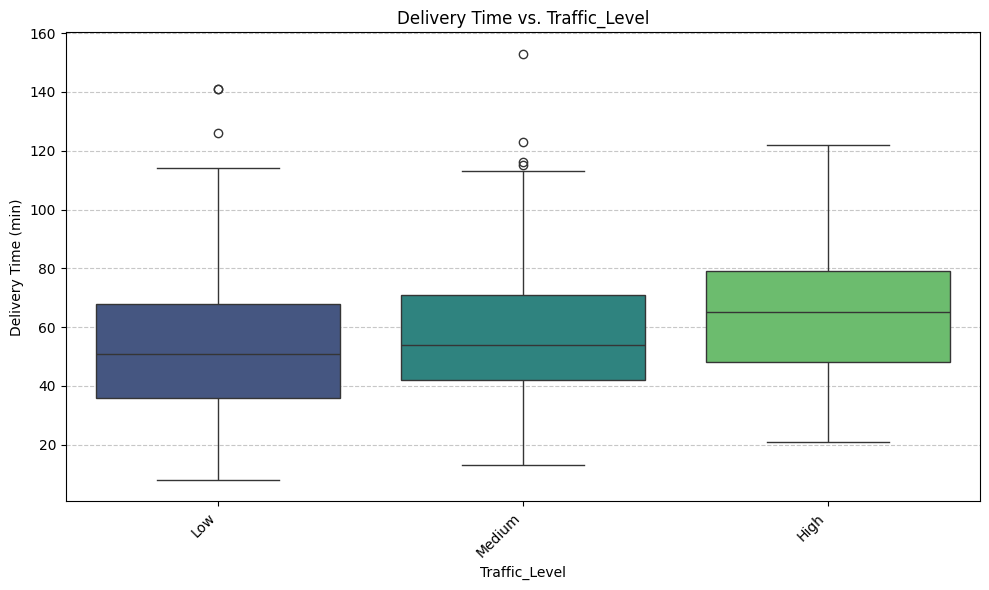

/tmp/ipykernel_3964/3564475273.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[feature], y=df['Delivery_Time_min'], palette='viridis')


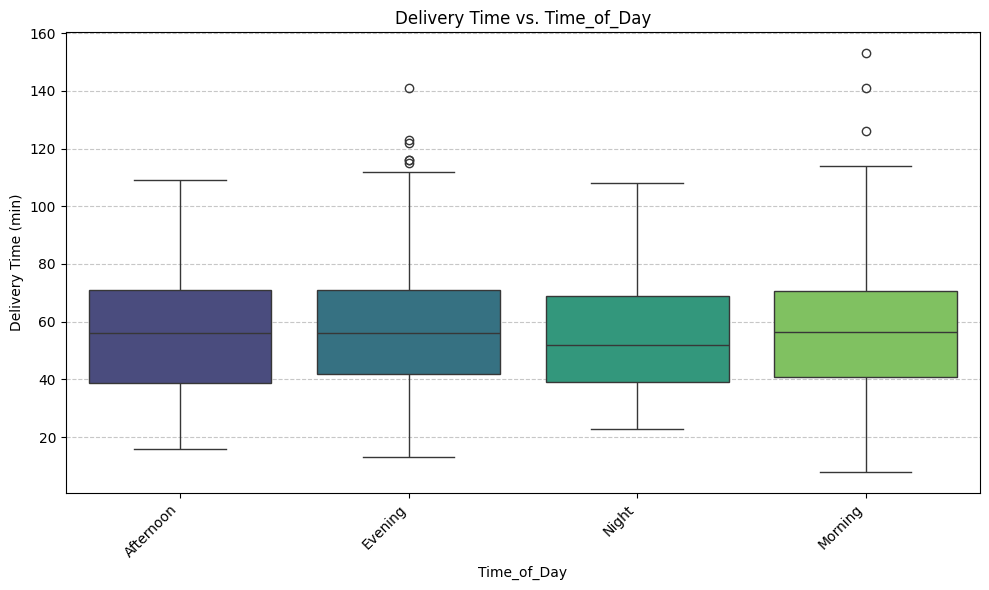

/tmp/ipykernel_3964/3564475273.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[feature], y=df['Delivery_Time_min'], palette='viridis')


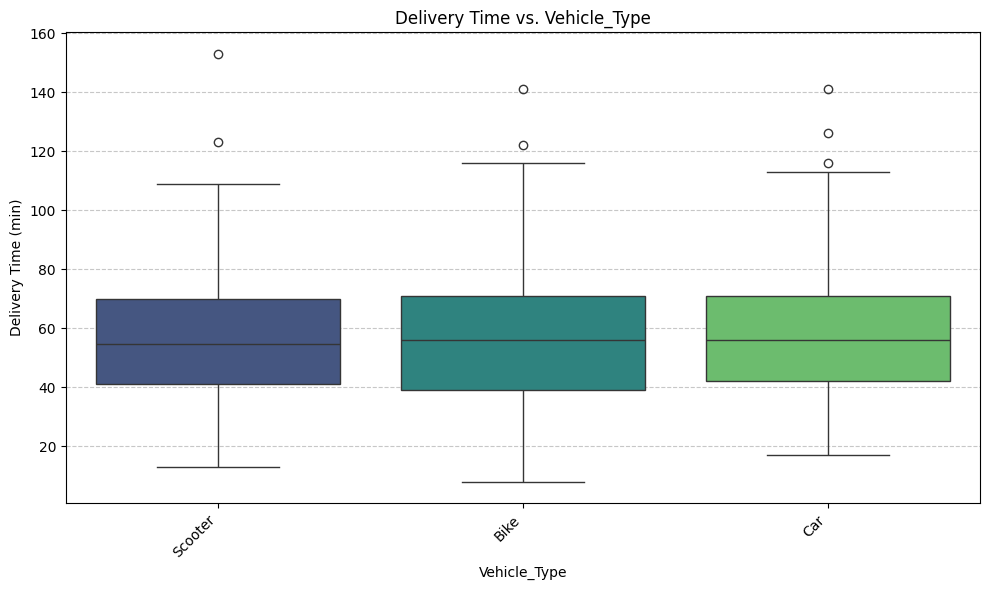

In [ ]:
categorical_features = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

for feature in categorical_features:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=df[feature], y=df['Delivery_Time_min'], palette='viridis')
    plt.title(f'Delivery Time vs. {feature}')
    plt.xlabel(feature)
    plt.ylabel('Delivery Time (min)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

### Statistical Testing for Feature Selection

To identify features that have a statistically significant relationship with `Delivery_Time_min`, we will perform:

*   **Pearson Correlation** for numerical features.
*   **ANOVA (Analysis of Variance)** for categorical features.

These tests will help us quantify the strength and significance of the relationships observed in the EDA.

#### 1. Numerical Feature Significance (Pearson Correlation)

In [ ]:
print("Pearson Correlation with Delivery_Time_min:")
for feature in numerical_features:
    correlation = df[feature].corr(df['Delivery_Time_min'])
    print(f"  {feature}: {correlation:.4f}")

Pearson Correlation with Delivery_Time_min:
  Distance_km: 0.7810
  Preparation_Time_min: 0.3073
  Courier_Experience_yrs: -0.0891


#### Interpretation of Numerical Feature Correlation:

*   A correlation close to `1` or `-1` indicates a strong linear relationship. `1` means as one increases, the other increases. `-1` means as one increases, the other decreases.
*   A correlation close to `0` indicates a weak or no linear relationship.

From the results, we can see that `Distance_km` and `Preparation_Time_min` have strong positive correlations with `Delivery_Time_min`, indicating they are highly influential. `Courier_Experience_yrs` has a weaker negative correlation.

#### 2. Categorical Feature Significance (ANOVA - Analysis of Variance)

In [ ]:
from scipy.stats import f_oneway

print("ANOVA F-statistic and p-value for Categorical Features:")
for feature in categorical_features:
    groups = [df['Delivery_Time_min'][df[feature] == g].values for g in df[feature].unique()]
    f_stat, p_value = f_oneway(*groups)
    print(f"  {feature}: F-statistic = {f_stat:.4f}, p-value = {p_value:.4f}")

ANOVA F-statistic and p-value for Categorical Features:
  Weather: F-statistic = 10.4991, p-value = 0.0000
  Traffic_Level: F-statistic = 19.7513, p-value = 0.0000
  Time_of_Day: F-statistic = 0.3468, p-value = 0.7915
  Vehicle_Type: F-statistic = 0.5894, p-value = 0.5549


#### Interpretation of ANOVA Results:

ANOVA tests the hypothesis that the means of two or more groups are equal.

*   **P-value:** The primary value to look at. If the p-value is less than a chosen significance level (commonly 0.05), it suggests that there is a statistically significant difference between the means of at least two groups. In the context of features, a low p-value means the categorical feature is likely influential on `Delivery_Time_min`.
*   **F-statistic:** A larger F-statistic (along with a small p-value) indicates greater differences between group means relative to the variability within the groups, suggesting a stronger effect of the categorical feature on the target variable.

Based on these results, any categorical feature with a p-value less than 0.05 can be considered statistically significant and a good candidate for inclusion in the model, as its different categories lead to significantly different average delivery times.

### Summary of Statistically Significant Features

By combining the insights from both Pearson correlation and ANOVA, we can identify the features most influential in predicting `Delivery_Time_min`:

*   **Numerical Features:**
    *   `Distance_km`: Shows a strong positive correlation (0.7810), indicating high statistical significance and impact on delivery time.
    *   `Preparation_Time_min`: Shows a moderate positive correlation (0.3073), also statistically significant.
    *   `Courier_Experience_yrs`: Shows a very weak negative correlation (-0.0891), suggesting a minimal linear relationship, and likely less significant.

*   **Categorical Features:**
    *   `Weather`: The p-value is 0.0000 (less than 0.05), indicating a highly statistically significant impact on `Delivery_Time_min`.
    *   `Traffic_Level`: The p-value is 0.0000 (less than 0.05), indicating a highly statistically significant impact on `Delivery_Time_min`.
    *   `Time_of_Day`: The p-value is 0.7915 (greater than 0.05), suggesting that different times of day do not have a statistically significant different average effect on `Delivery_Time_min` based on this test.
    *   `Vehicle_Type`: The p-value is 0.5549 (greater than 0.05), suggesting that different vehicle types do not have a statistically significant different average effect on `Delivery_Time_min` based on this test.

**Conclusion:**

Based on these statistical tests, `Distance_km`, `Preparation_Time_min`, `Weather`, and `Traffic_Level` are the features that show strong statistical significance and are good candidates to consider for building a predictive model. `Courier_Experience_yrs`, `Time_of_Day`, and `Vehicle_Type` appear to have less statistical impact, especially `Time_of_Day` and `Vehicle_Type` which did not pass the ANOVA significance test. This doesn't mean they are completely irrelevant, but their direct average effect on `Delivery_Time_min` is not statistically significant in this dataset.

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Weather'] = le.fit_transform(df['Weather'])
df['Traffic_Level'] = le.fit_transform(df['Traffic_Level'])
df['Time_of_Day'] = le.fit_transform(df['Time_of_Day'])
df['Vehicle_Type'] = le.fit_transform(df['Vehicle_Type'])

In [ ]:
x = df.drop(['Delivery_Time_min'], axis = 1)
y = df['Delivery_Time_min']

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

### Build and Train a Decision Tree Regressor Model

Now, we will build a Decision Tree Regressor model using `sklearn.tree.DecisionTreeRegressor`. We will use its default parameters for this initial pass. After training, we will evaluate its performance on the test set using the R-squared metric.

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

# Initialize the Decision Tree Regressor with default parameters
dtree_model = DecisionTreeRegressor(random_state=42)

# Train the model
dtree_model.fit(x_train, y_train)

# Make predictions on the test set
y_pred = dtree_model.predict(x_test)

# Evaluate the model using R-squared
r2 = r2_score(y_test, y_pred)
print(f"Decision Tree Regressor R-squared score: {r2:.4f}")

Decision Tree Regressor R-squared score: 0.4939


### Build and Train a Random Forest Regressor Model

Now, let's build a Random Forest Regressor model, which is an ensemble learning method known for its robustness and accuracy. We'll use default parameters for now and evaluate its R-squared score on the test set.

In [ ]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor with default parameters
rf_model = RandomForestRegressor(random_state=42)

# Train the model
rf_model.fit(x_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(x_test)

# Evaluate the model using R-squared
r2_rf = r2_score(y_test, y_pred_rf)
print(f"Random Forest Regressor R-squared score: {r2_rf:.4f}")

Random Forest Regressor R-squared score: 0.7761


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

# Define the parameter distributions for RandomizedSearchCV
param_dist = {
    'n_estimators': randint(low=100, high=500), # Number of trees in the forest
    'max_features': ['sqrt', 'log2'], # Number of features to consider at each split
    'max_depth': randint(low=5, high=50), # Maximum depth of the tree
    'min_samples_split': randint(low=2, high=20), # Minimum number of samples required to split an internal node
    'min_samples_leaf': randint(low=1, high=10), # Minimum number of samples required to be at a leaf node
    'bootstrap': [True, False] # Whether bootstrap samples are used when building trees
}

# Initialize RandomizedSearchCV
random_search_rf = RandomizedSearchCV(
    estimator=RandomForestRegressor(random_state=42), # Use RandomForestRegressor as the estimator
    param_distributions=param_dist,
    n_iter=50, # Number of parameter settings that are sampled (adjust based on computational budget)
    cv=3, # 3-fold cross-validation
    n_jobs=-1, # Use all available cores
    verbose=2, # Display progress messages
    scoring='r2', # Optimize for R-squared score
    random_state=42 # For reproducibility
)

# Fit RandomizedSearchCV to the training data
random_search_rf.fit(x_train, y_train)

# Print the best parameters found
print(f"Best parameters found by RandomizedSearchCV: {random_search_rf.best_params_}")

# Get the best model
best_rf_model_random = random_search_rf.best_estimator_

# Make predictions with the best model
y_pred_best_rf_random = best_rf_model_random.predict(x_test)

# Evaluate the best model
r2_best_rf_random = r2_score(y_test, y_pred_best_rf_random)
print(f"R-squared score with best parameters (RandomizedSearchCV): {r2_best_rf_random:.4f}")

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best parameters found by RandomizedSearchCV: {'bootstrap': True, 'max_depth': 22, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 3, 'n_estimators': 409}
R-squared score with best parameters (RandomizedSearchCV): 0.7856


### Saving the LabelEncoders and the Best Random Forest Model

To use the trained model in a frontend application, we need to save the preprocessing steps (like the `LabelEncoder` for categorical features) and the final trained model. We'll use Python's `pickle` module for this.

In [ ]:
import pickle
from sklearn.preprocessing import LabelEncoder

# Define the categorical features again (as used during training)
categorical_features_to_encode = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

# Create a dictionary to store fitted LabelEncoders
label_encoders = {}

# Fit and store LabelEncoders for each categorical feature
# It's important to fit them on the original 'df' column values
# to capture all possible categories, just as it was done for model training.
for feature in categorical_features_to_encode:
    le = LabelEncoder()
    le.fit(df[feature]) # Assuming 'df' still holds the original categorical values before encoding
    label_encoders[feature] = le

# Save the dictionary of LabelEncoders
with open('label_encoders.pkl', 'wb') as file:
    pickle.dump(label_encoders, file)

print("LabelEncoders saved to 'label_encoders.pkl'")

LabelEncoders saved to 'label_encoders.pkl'


In [ ]:
# Save the best Random Forest model found by RandomizedSearchCV
with open('random_forest_model.pkl', 'wb') as file:
    pickle.dump(best_rf_model_random, file)

print("Random Forest Model saved to 'random_forest_model.pkl'")

Random Forest Model saved to 'random_forest_model.pkl'


To verify that the files have been created and to see their location, you can list the contents of the current directory:

In [ ]:
!ls

'Food_Delivery_Times (1).csv'   random_forest_model.pkl
 label_encoders.pkl	        sample_data
